In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv("C:\\Users\\Admin\\OneDrive\\Desktop\\MachineLearning\\UNSUPERVISED_ML\\K_MEAN\\k_mean_employees_grouping\\employee_wellness_data.csv")
print(df.isnull().sum())
print(df.describe())
print(df.head(4))

df["MonthlyIncome_USD"] =  df["MonthlyIncome_USD"].fillna(df["MonthlyIncome_USD"].mean())

print(df.columns)

EmployeeID               0
Age                      0
Department               0
JobRole                  0
Education                0
MaritalStatus            0
MonthlyIncome_USD        7
YearsAtCompany           0
OvertimeHoursPerWeek     0
WorkLifeBalanceScore     0
JobSatisfactionScore     0
DistanceFromHome_KM      0
TrainingHoursLastYear    0
NumProjectsHandled       0
Attrition                0
dtype: int64
         EmployeeID         Age  MonthlyIncome_USD  YearsAtCompany  \
count    200.000000  200.000000         193.000000      200.000000   
mean   20100.500000   34.385000        4890.513731        5.430000   
std       57.879185    8.993397        2077.656902        5.046029   
min    20001.000000   23.000000        1821.030000        1.000000   
25%    20050.750000   26.000000        3248.620000        2.000000   
50%    20100.500000   33.000000        4045.880000        3.000000   
75%    20150.250000   41.000000        6254.050000        8.000000   
max    20200.000000   

In [5]:
# print(df["MonthlyIncome_USD"])

# print(df.isnull().sum())
print(df.dtypes)


EmployeeID                 int64
Age                        int64
Department                   str
JobRole                      str
Education                    str
MaritalStatus                str
MonthlyIncome_USD        float64
YearsAtCompany             int64
OvertimeHoursPerWeek     float64
WorkLifeBalanceScore     float64
JobSatisfactionScore     float64
DistanceFromHome_KM      float64
TrainingHoursLastYear    float64
NumProjectsHandled         int64
Attrition                    str
dtype: object


In [6]:
df_new = df.drop(columns=["EmployeeID","Attrition"])
df_encoded = pd.get_dummies(df_new,columns=["Department","JobRole","Education","MaritalStatus"])
df_encoded.to_excel("df_encoded.xlsx", index=False)
print(df_encoded)

     Age  MonthlyIncome_USD  YearsAtCompany  OvertimeHoursPerWeek  \
0     40        4507.250000               4                   2.4   
1     24        4890.513731               3                  18.0   
2     37        4890.513731               4                  11.4   
3     45        5381.940000               7                   9.1   
4     29        3118.730000               1                  13.1   
..   ...                ...             ...                   ...   
195   41        6254.050000              19                   0.8   
196   48        4890.513731              13                   4.0   
197   50        8085.040000              11                   0.0   
198   40        5874.300000               4                  19.1   
199   24        3250.720000               2                  11.0   

     WorkLifeBalanceScore  JobSatisfactionScore  DistanceFromHome_KM  \
0                     3.7                   2.4                 20.7   
1                     3.0  

In [7]:
scaler = StandardScaler()

df_scaler  = scaler.fit_transform(df_encoded)

In [8]:
print(df_scaler)

[[ 0.62591373 -0.1882731  -0.28410228 ... -0.65465367 -0.73379939
   1.36277029]
 [-1.15763385  0.         -0.48277521 ... -0.65465367  1.36277029
  -0.73379939]
 [ 0.29149856  0.         -0.28410228 ...  1.52752523 -0.73379939
  -0.73379939]
 ...
 [ 1.74063097  1.56926763  1.1066082  ...  1.52752523 -0.73379939
  -0.73379939]
 [ 0.62591373  0.48327164 -0.28410228 ... -0.65465367 -0.73379939
   1.36277029]
 [-1.15763385 -0.80552639 -0.68144814 ... -0.65465367 -0.73379939
   1.36277029]]


[6999.999999999999, 6355.449665147742, 5973.354052846426, 5587.261991236181, 5099.8441263342775, 4613.063158121125, 4378.675236948695, 4219.9419520804595, 3985.55403090803, 3873.8314631962867]


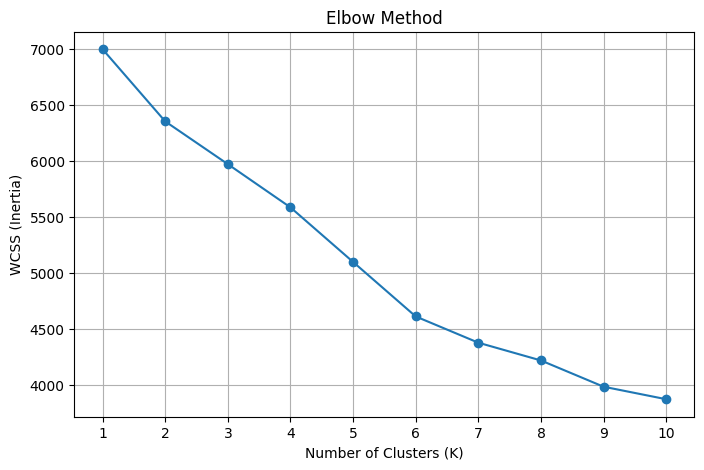

In [9]:


wcss = []

# Elbow Method
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(df_scaler)
    wcss.append(kmeans.inertia_)
print(wcss)
# Graph
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(range(1,11))
plt.grid(True)

plt.show()

In [10]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaler)

    score = silhouette_score(df_scaler, labels)
    print(f"K={k}  Score={score:.3f}")

K=2  Score=0.092
K=3  Score=0.081
K=4  Score=0.101
K=5  Score=0.157
K=6  Score=0.195
K=7  Score=0.208
K=8  Score=0.169
K=9  Score=0.188
K=10  Score=0.179


In [11]:
kmeans =KMeans(n_clusters=7,random_state=42)

kmeans.fit(df_scaler)

print(kmeans.labels_)

print(kmeans.cluster_centers_)

[5 3 3 4 3 3 3 2 5 6 2 4 0 2 3 3 0 5 4 0 1 6 4 0 3 2 4 0 3 0 5 2 4 4 4 2 0
 3 5 5 4 6 2 3 3 0 5 0 0 4 3 4 2 6 4 3 4 5 3 4 6 3 4 2 4 3 2 1 6 2 4 5 3 6
 0 3 3 1 5 4 4 5 0 1 0 2 5 3 6 2 2 5 6 4 3 4 2 0 5 5 4 4 3 2 5 0 2 0 5 5 6
 3 5 5 0 1 3 1 3 3 1 2 1 0 0 1 2 3 3 2 3 5 2 3 2 2 5 3 5 6 3 5 4 3 0 6 0 3
 4 0 4 6 3 3 0 5 0 4 3 3 5 1 0 2 3 0 0 1 6 6 5 5 0 5 2 3 3 2 0 4 2 3 5 6 2
 4 3 5 5 2 2 3 4 1 3 5 6 2 6 5]
[[ 1.30056751e-01 -6.87789328e-02  5.84372435e-02  1.61402720e-01
   2.25270130e-02  2.75259183e-01 -3.18957220e-02 -1.14944970e-01
  -2.83106915e-02  2.42828164e+00 -5.46535725e-01 -4.52569638e-01
  -4.28289566e-01 -4.20084025e-01 -4.20084025e-01 -3.51561525e-01
  -3.69274473e-01 -3.23994407e-01 -2.84747399e-01 -2.52645576e-01
  -3.23994407e-01 -3.04788738e-01 -2.63664022e-01  1.03698595e+00
  -2.52645576e-01 -3.14485451e-01  1.42253694e+00  1.48973771e+00
  -4.48477722e-03 -2.52387785e-01  3.15337838e-02  2.66242715e-01
  -2.03168381e-01 -1.08443259e-02  2.06042192e-01]
 [ 1.28192483e

In [12]:
df["CLUSTERS"] = kmeans.labels_
print(df.columns)

df.to_csv("df_with_cluster.csv")

Index(['EmployeeID', 'Age', 'Department', 'JobRole', 'Education',
       'MaritalStatus', 'MonthlyIncome_USD', 'YearsAtCompany',
       'OvertimeHoursPerWeek', 'WorkLifeBalanceScore', 'JobSatisfactionScore',
       'DistanceFromHome_KM', 'TrainingHoursLastYear', 'NumProjectsHandled',
       'Attrition', 'CLUSTERS'],
      dtype='str')


In [13]:
df_new_cluster = pd.read_csv("C:\\Users\\Admin\\OneDrive\\Desktop\\MachineLearning\\UNSUPERVISED_ML\\K_MEAN\\k_mean_employees_grouping\\df_with_cluster.csv")
print(df_new_cluster["CLUSTERS"].value_counts())

CLUSTERS
3    46
5    34
2    31
4    30
0    29
6    18
1    12
Name: count, dtype: int64


In [14]:
df0 = df_new_cluster[df_new_cluster["CLUSTERS"] == 0]
df1 = df_new_cluster[df_new_cluster["CLUSTERS"] == 1]
df2 = df_new_cluster[df_new_cluster["CLUSTERS"] == 2]
df3 = df_new_cluster[df_new_cluster["CLUSTERS"] == 3]
df4 = df_new_cluster[df_new_cluster["CLUSTERS"] == 4]
df5 = df_new_cluster[df_new_cluster["CLUSTERS"] == 5]
df6 = df_new_cluster[df_new_cluster["CLUSTERS"] == 6]


In [15]:
print(df0.describe())

df0.to_excel("cluster0.xlsx",index=False)

       Unnamed: 0    EmployeeID        Age  MonthlyIncome_USD  YearsAtCompany  \
count   29.000000     29.000000  29.000000          29.000000       29.000000   
mean    96.689655  20097.689655  35.551724        4750.501853        5.724138   
std     56.319943     56.319943   9.504083        1965.339929        5.357882   
min     12.000000  20013.000000  23.000000        2458.870000        1.000000   
25%     45.000000  20046.000000  27.000000        3202.440000        2.000000   
50%    105.000000  20106.000000  33.000000        4346.680000        3.000000   
75%    149.000000  20150.000000  45.000000        5580.370000        7.000000   
max    178.000000  20179.000000  54.000000        9368.130000       19.000000   

       OvertimeHoursPerWeek  WorkLifeBalanceScore  JobSatisfactionScore  \
count             29.000000             29.000000             29.000000   
mean               9.810345              3.141379              3.458621   
std                8.377408              0.96

In [16]:
print(df1.describe())
df1.to_excel("cluster1.xlsx",index=False)

       Unnamed: 0    EmployeeID        Age  MonthlyIncome_USD  YearsAtCompany  \
count   12.000000     12.000000  12.000000          12.000000       12.000000   
mean   113.916667  20114.916667  34.500000        4424.600000        4.666667   
std     47.544158     47.544158  10.352865        2375.354054        4.658001   
min     20.000000  20021.000000  24.000000        2686.180000        1.000000   
25%     81.500000  20082.500000  25.000000        3174.425000        1.000000   
50%    118.500000  20119.500000  30.500000        3535.585000        3.000000   
75%    134.000000  20135.000000  44.750000        4175.310000        6.500000   
max    193.000000  20194.000000  52.000000       10635.720000       17.000000   

       OvertimeHoursPerWeek  WorkLifeBalanceScore  JobSatisfactionScore  \
count             12.000000             12.000000             12.000000   
mean              10.141667              2.758333              2.491667   
std                3.832032              0.98

In [17]:
print(df2.describe())
df2.to_excel("cluster2.xlsx",index=False)

       Unnamed: 0    EmployeeID        Age  MonthlyIncome_USD  YearsAtCompany  \
count   31.000000     31.000000  31.000000          31.000000       31.000000   
mean   103.645161  20104.645161  34.290323        5182.292258        6.161290   
std     59.944724     59.944724   8.462441        2149.589206        5.698519   
min      7.000000  20008.000000  23.000000        2478.480000        1.000000   
25%     57.500000  20058.500000  27.000000        3351.015000        2.000000   
50%    103.000000  20104.000000  33.000000        4353.990000        3.000000   
75%    149.000000  20150.000000  41.000000        6956.285000        8.500000   
max    197.000000  20198.000000  50.000000        9393.380000       18.000000   

       OvertimeHoursPerWeek  WorkLifeBalanceScore  JobSatisfactionScore  \
count             31.000000             31.000000             31.000000   
mean               9.400000              3.167742              3.135484   
std                8.935435              0.99

In [18]:
print(df3.describe())
df3.to_excel("cluster3.xlsx",index=False)

       Unnamed: 0    EmployeeID        Age  MonthlyIncome_USD  YearsAtCompany  \
count   46.000000     46.000000  46.000000          46.000000       46.000000   
mean    96.869565  20097.869565  34.043478        4578.156492        4.760870   
std     60.316797     60.316797   9.079786        1854.356718        4.517545   
min      1.000000  20002.000000  23.000000        1821.030000        1.000000   
25%     45.500000  20046.500000  26.000000        3145.217500        1.000000   
50%    106.500000  20107.500000  31.000000        4359.620000        2.500000   
75%    146.000000  20147.000000  40.500000        5153.282500        7.750000   
max    194.000000  20195.000000  54.000000       10511.660000       19.000000   

       OvertimeHoursPerWeek  WorkLifeBalanceScore  JobSatisfactionScore  \
count             46.000000             46.000000             46.000000   
mean               9.017391              2.921739              2.852174   
std                4.873206              0.94

In [19]:
print(df4.describe())
df4.to_excel("cluster4.xlsx",index=False)

       Unnamed: 0    EmployeeID        Age  MonthlyIncome_USD  YearsAtCompany  \
count   30.000000     30.000000  30.000000          30.000000       30.000000   
mean    79.500000  20080.500000  35.600000        5659.343667        6.266667   
std     54.807972     54.807972   8.822385        2309.272321        5.185745   
min      3.000000  20004.000000  23.000000        2670.360000        1.000000   
25%     35.500000  20036.500000  27.000000        3469.995000        2.000000   
50%     63.000000  20064.000000  38.000000        5319.665000        6.500000   
75%    100.750000  20101.750000  42.500000        7815.170000        8.000000   
max    192.000000  20193.000000  52.000000        9713.250000       19.000000   

       OvertimeHoursPerWeek  WorkLifeBalanceScore  JobSatisfactionScore  \
count              30.00000             30.000000             30.000000   
mean                7.64000              3.433333              3.516667   
std                 7.99002              0.92

In [20]:
print(df5.describe())
df5.to_excel("cluster5.xlsx",index=False)

       Unnamed: 0    EmployeeID        Age  MonthlyIncome_USD  YearsAtCompany  \
count   34.000000     34.000000  34.000000          34.000000       34.000000   
mean   109.147059  20110.147059  31.117647        4452.030882        4.294118   
std     57.819014     57.819014   8.119429        1820.991043        4.648424   
min      0.000000  20001.000000  23.000000        2456.020000        1.000000   
25%     72.750000  20073.750000  25.000000        3242.297500        1.000000   
50%    108.500000  20109.500000  27.500000        3902.660000        2.000000   
75%    158.750000  20159.750000  36.250000        4837.190000        5.000000   
max    199.000000  20200.000000  51.000000        9281.260000       19.000000   

       OvertimeHoursPerWeek  WorkLifeBalanceScore  JobSatisfactionScore  \
count             34.000000             34.000000             34.000000   
mean               7.070588              3.141176              3.350000   
std                4.949535              0.91

In [21]:
print(df6.describe())
df6.to_excel("cluster6.xlsx",index=False)

       Unnamed: 0    EmployeeID        Age  MonthlyIncome_USD  YearsAtCompany  \
count   18.000000     18.000000  18.000000          18.000000       18.000000   
mean   109.111111  20110.111111  37.611111        5269.298541        6.666667   
std     61.174667     61.174667   9.255452        1940.125778        5.423261   
min      9.000000  20010.000000  24.000000        2867.580000        1.000000   
25%     62.000000  20063.000000  29.750000        3780.922500        2.000000   
50%    101.000000  20102.000000  37.500000        4712.380000        5.000000   
75%    163.750000  20164.750000  45.000000        6141.167500       11.000000   
max    198.000000  20199.000000  54.000000        9318.010000       18.000000   

       OvertimeHoursPerWeek  WorkLifeBalanceScore  JobSatisfactionScore  \
count             18.000000             18.000000             18.000000   
mean               8.966667              3.188889              3.038889   
std                6.514328              0.91